# ITCS 6169/8169 — Computer Vision
## Assignment 1: The CNN Challenge
**Due: September 25, 2026 at 11:59 PM EDT**

---

In this assignment, you will build and train a convolutional neural network (CNN) for **16-class scene recognition** using a small dataset of **2,400 training images**.

This notebook is intentionally only a **starter baseline**. It provides a clean training pipeline and a deliberately simple CNN. Your task is to improve the system through informed decisions about architecture, optimization, augmentation, regularization, model selection, and training strategy.

### 2026 workflow: AI is your pair programmer
Use of an AI coding assistant (e.g., ChatGPT, Codex, GitHub Copilot, Claude Code, Gemini, Cursor) is **required**. You may use AI to help implement, debug, refactor, explain, or suggest experiments. However, **you are responsible for the scientific decisions and for verifying all generated code**.

Your final GitHub repository must include an `AI_USAGE.md` file describing representative AI-assisted tasks, at least one incorrect/ineffective AI suggestion, how you verified or corrected it, and one important decision that you made yourself.

### Important model restriction
The primary classifier for Assignment 1 must be a **CNN**. Do **not** use CLIP, DINO/DINOv2, VLM APIs, Vision Transformers as the primary model, or other foundation-model embeddings for your main submission. Pretrained CNNs are allowed if clearly documented.

### Google Colab
Google Colab is recommended, but not required. If using Colab, enable a GPU through **Runtime → Change runtime type → GPU**. You may also use the Educational Cluster or another resource for which you have authorized access.

In [1]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA available: True


In [15]:
# Optional: mount Google Drive when running in Colab.
# Skip this cell if you are running locally or on another server.
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print("Not running in Google Colab; Drive mount skipped.")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Experiment Log

## Experiment 0 — Starter CNN Baseline

### Objective
Establish the performance of the provided starter CNN before making any modifications.

### Changes
No modifications to the starter training pipeline.

### Configuration
- Architecture: Starter CNN
- Input size: 64 × 64
- Input channels: Grayscale
- Optimizer: Adam
- Learning rate: 0.002
- Epochs: 20
- Validation split: 80/20
- Loss: Cross Entropy

### Results
- Best validation accuracy: TBD
- Best epoch: TBD
- Training time: TBD

### Observation
TBD

### Decision
TBD

## 1. Set your working directory

Download the assignment dataset from the link provided in the assignment handout and organize it so that the notebook can find:

```text
data/
  train/
    class_1/
    ...
  test/
    class_1/
    ...
```

If you use Google Drive, change `PROJECT_ROOT` below to your assignment folder. **Do not hard-code a TA/instructor solution path.**

In [16]:
# CHANGE THIS PATH to your own assignment directory.
# Example for Colab + Google Drive:
# PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169_8169/assignment1')

PROJECT_ROOT = Path('.')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: /content
Training data: data/train
Testing data: data/test


## 2. Reproducibility and device

A fixed seed makes the starter result easier to reproduce. Exact GPU reproducibility is not always guaranteed across hardware/software versions, so report your environment and seed in the final repository.

In [17]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Loading and preprocessing the data

The starter baseline converts images to grayscale and resizes them to $64\times64$. This is **not necessarily a good final choice**. You should decide whether color, resolution, normalization, and augmentation should be changed.

We split the provided training data into **training and validation sets**. Use the validation set for architecture/hyperparameter decisions. **Do not repeatedly tune on the test set.** The test set should be used for the final evaluation of a selected model.

In [18]:
IMG_SIZE = 64
BATCH_SIZE = 64
VAL_FRACTION = 0.20

import zipfile
import os

# Create the data directory if it doesn't exist (already created by DATA_ROOT = PROJECT_ROOT / 'data')
os.makedirs(DATA_ROOT, exist_ok=True)

# Unzip train.zip if it exists
train_zip_path = DATA_ROOT / 'train.zip'
if train_zip_path.exists() and not (DATA_ROOT / 'train').exists():
    with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_ROOT)
    print(f"Extracted {train_zip_path} to {DATA_ROOT}")
elif not train_zip_path.exists():
    print(f"Warning: {train_zip_path} not found. Please ensure your dataset is correctly placed.")

# Unzip test.zip if it exists
test_zip_path = DATA_ROOT / 'test.zip'
if test_zip_path.exists() and not (DATA_ROOT / 'test').exists():
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_ROOT)
    print(f"Extracted {test_zip_path} to {DATA_ROOT}")
elif not test_zip_path.exists():
    print(f"Warning: {test_zip_path} not found. Please ensure your dataset is correctly placed.")

# Deliberately simple preprocessing for the starter baseline.
# TODO: improve this as part of your experiments.
baseline_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

full_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=baseline_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=baseline_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(full_train_dataset)}')
print(f'Test images: {len(test_dataset)}')

val_size = int(round(len(full_train_dataset) * VAL_FRACTION))
train_size = len(full_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2400
Test images: 400
Train: 1920 | Validation: 480 | Test: 400


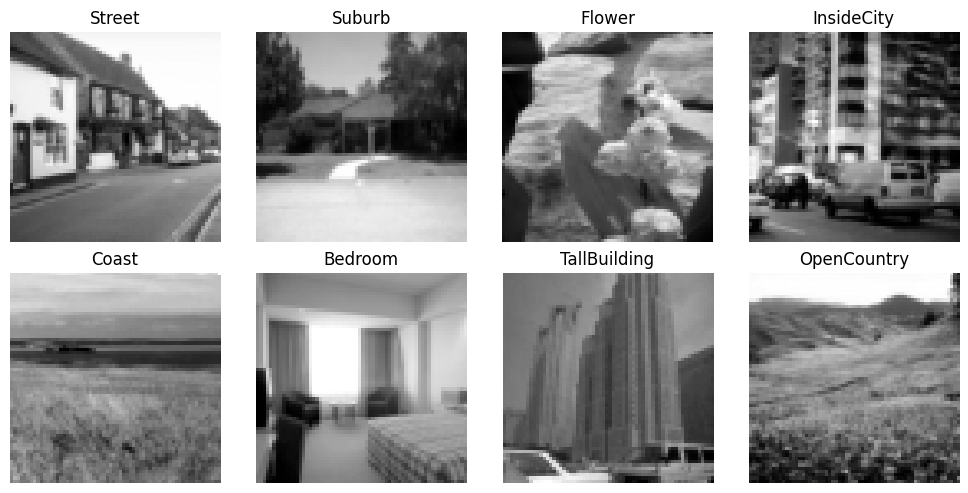

In [19]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training a CNN from scratch

Gone are the days when hand-designed features were the default solution. We will start with end-to-end learning and train a CNN directly for 16-way classification.

The architecture below is deliberately weak and simple. **Do not treat it as a recommended architecture.** It exists only to verify that the pipeline works and to give you a baseline to beat.

In [20]:
class TNet(nn.Module):
    """A deliberately small CNN starter baseline."""
    def __init__(self, num_classes=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 15 * 15, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TNet(num_classes=num_classes)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3600, out_features=16, bias=True)
  )
)
Trainable parameters: 57,776


## 5. Training and evaluation utilities

The training loop below selects the checkpoint with the **best validation accuracy**. This is a much better experimental practice than evaluating the test set after every epoch.

You are welcome to rewrite this code. For example, you may add a scheduler, mixed precision, early stopping, checkpointing, experiment tracking, or richer metrics. If AI helps you implement such changes, verify the implementation and document representative usage in `AI_USAGE.md`.

In [21]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [22]:
# Train the deliberately simple baseline.
set_random_seed(SEED)
model = TNet(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=20, device=device
)

Epoch 01/20 | train loss 2.5592 | val loss 2.2293 | val acc 0.3250 | 3.4s
Epoch 02/20 | train loss 2.0026 | val loss 2.0162 | val acc 0.3833 | 6.0s
Epoch 03/20 | train loss 1.6781 | val loss 1.8858 | val acc 0.4062 | 8.6s
Epoch 04/20 | train loss 1.3858 | val loss 1.8122 | val acc 0.4333 | 11.2s
Epoch 05/20 | train loss 1.1467 | val loss 1.7489 | val acc 0.4479 | 14.9s
Epoch 06/20 | train loss 1.0055 | val loss 1.8056 | val acc 0.4583 | 18.2s
Epoch 07/20 | train loss 0.8224 | val loss 1.7448 | val acc 0.4542 | 20.8s
Epoch 08/20 | train loss 0.6843 | val loss 1.7903 | val acc 0.4625 | 23.5s
Epoch 09/20 | train loss 0.5994 | val loss 1.8055 | val acc 0.4771 | 26.1s
Epoch 10/20 | train loss 0.5056 | val loss 1.9016 | val acc 0.4562 | 30.1s
Epoch 11/20 | train loss 0.4428 | val loss 1.8477 | val acc 0.4979 | 33.4s
Epoch 12/20 | train loss 0.3769 | val loss 1.9473 | val acc 0.4625 | 36.0s
Epoch 13/20 | train loss 0.3261 | val loss 1.9897 | val acc 0.4750 | 38.6s
Epoch 14/20 | train loss 0.2

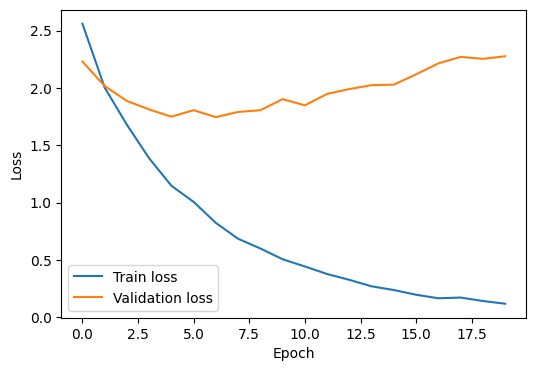

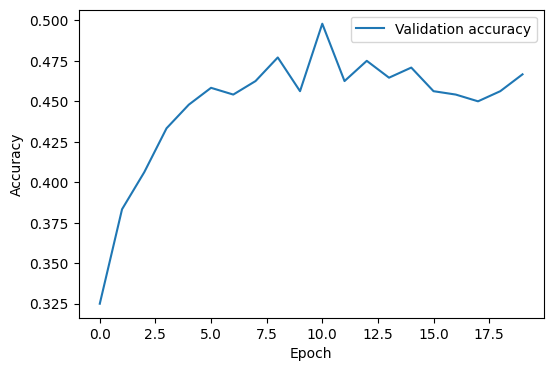

In [23]:
# Plot the starter training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Experiment 1 — ImageNet-Pretrained ResNet18

## Hypothesis

The starter CNN achieved a best validation accuracy of 49.79% but showed substantial overfitting. Its training loss continued decreasing while validation loss increased after the early epochs.

The baseline also discards color information, uses only 64 × 64 resolution, and learns visual features entirely from the small training dataset.

For this experiment, I test whether transfer learning from an ImageNet-pretrained ResNet18 can improve generalization. The model receives 224 × 224 RGB images using ImageNet normalization. The original train/validation split is preserved using the same random seed so that the validation result remains directly comparable with the baseline.

In [25]:
# ============================================================
# EXPERIMENT 1: RGB + ImageNet preprocessing
# ============================================================

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

EXP1_IMG_SIZE = 224
EXP1_BATCH_SIZE = 64

# ImageNet normalization expected by pretrained ResNet models
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

exp1_transform = transforms.Compose([
    transforms.Resize((EXP1_IMG_SIZE, EXP1_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Create dataset with the new RGB/ImageNet transform.
exp1_full_dataset = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp1_transform
)

# ------------------------------------------------------------
# Reproduce EXACTLY the same random split used by Experiment 0.
# ------------------------------------------------------------

exp1_val_size = int(round(len(exp1_full_dataset) * VAL_FRACTION))
exp1_train_size = len(exp1_full_dataset) - exp1_val_size

split_generator = torch.Generator().manual_seed(SEED)

train_indices, val_indices = torch.utils.data.random_split(
    range(len(exp1_full_dataset)),
    [exp1_train_size, exp1_val_size],
    generator=split_generator
)

train_indices = list(train_indices)
val_indices = list(val_indices)

exp1_train_dataset = Subset(exp1_full_dataset, train_indices)
exp1_val_dataset = Subset(exp1_full_dataset, val_indices)

exp1_train_loader = DataLoader(
    exp1_train_dataset,
    batch_size=EXP1_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

exp1_val_loader = DataLoader(
    exp1_val_dataset,
    batch_size=EXP1_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Experiment 1 dataset ready")
print("Training samples:", len(exp1_train_dataset))
print("Validation samples:", len(exp1_val_dataset))

images, labels = next(iter(exp1_train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Experiment 1 dataset ready
Training samples: 1920
Validation samples: 480
Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])


In [26]:
# ============================================================
# EXPERIMENT 1: Pretrained ResNet18
# ============================================================

from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

exp1_model = resnet18(weights=weights)

# Replace the original ImageNet 1000-class classifier
# with a classifier for our 16 scene classes.
num_features = exp1_model.fc.in_features
exp1_model.fc = nn.Linear(num_features, num_classes)

exp1_model = exp1_model.to(device)

total_params = sum(p.numel() for p in exp1_model.parameters())
trainable_params = sum(
    p.numel() for p in exp1_model.parameters()
    if p.requires_grad
)

print(exp1_model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Final classifier:", exp1_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
# ============================================================
# EXPERIMENT 1: Training configuration
# ============================================================

set_random_seed(SEED)

criterion = nn.CrossEntropyLoss()

exp1_optimizer = optim.Adam(
    exp1_model.parameters(),
    lr=1e-4
)

print("Experiment 1 configuration")
print("--------------------------")
print("Model: ResNet18")
print("Pretraining: ImageNet")
print("Input: 224 x 224 RGB")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: CrossEntropyLoss")
print("Epochs: 10")

Experiment 1 configuration
--------------------------
Model: ResNet18
Pretraining: ImageNet
Input: 224 x 224 RGB
Optimizer: Adam
Learning rate: 0.0001
Loss: CrossEntropyLoss
Epochs: 10


In [28]:
exp1_model, exp1_history = train_model(
    exp1_model,
    exp1_train_loader,
    exp1_val_loader,
    exp1_optimizer,
    epochs=10,
    device=device
)

Epoch 01/10 | train loss 1.2476 | val loss 0.3885 | val acc 0.9146 | 9.9s
Epoch 02/10 | train loss 0.2326 | val loss 0.2502 | val acc 0.9333 | 18.1s
Epoch 03/10 | train loss 0.0843 | val loss 0.2425 | val acc 0.9333 | 27.8s
Epoch 04/10 | train loss 0.0359 | val loss 0.2320 | val acc 0.9333 | 36.7s
Epoch 05/10 | train loss 0.0201 | val loss 0.2199 | val acc 0.9229 | 46.4s
Epoch 06/10 | train loss 0.0140 | val loss 0.2209 | val acc 0.9271 | 56.2s
Epoch 07/10 | train loss 0.0106 | val loss 0.2181 | val acc 0.9313 | 65.1s
Epoch 08/10 | train loss 0.0079 | val loss 0.2184 | val acc 0.9271 | 74.4s
Epoch 09/10 | train loss 0.0063 | val loss 0.2221 | val acc 0.9313 | 84.1s
Epoch 10/10 | train loss 0.0059 | val loss 0.2201 | val acc 0.9292 | 94.3s
Best validation accuracy: 0.9333


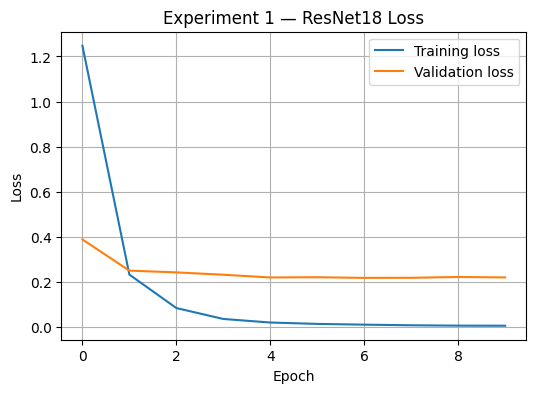

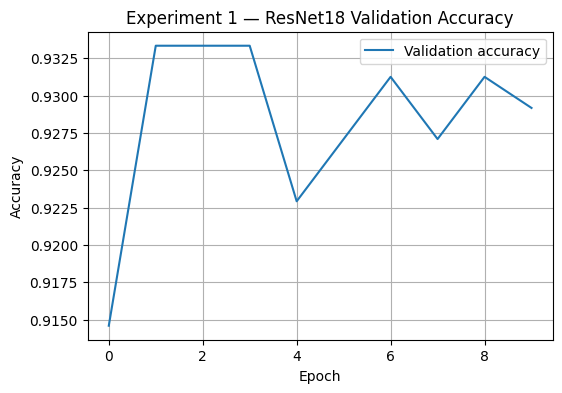

Best Experiment 1 validation accuracy: 0.9333
Best Experiment 1 validation accuracy (%): 93.33%
Best Experiment 1 epoch: 2


In [29]:
# ============================================================
# EXPERIMENT 1: Learning curves
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(exp1_history['train_loss'], label='Training loss')
plt.plot(exp1_history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 1 — ResNet18 Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(exp1_history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 1 — ResNet18 Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

best_exp1_acc = max(exp1_history['val_acc'])
best_exp1_epoch = exp1_history['val_acc'].index(best_exp1_acc) + 1

print(f"Best Experiment 1 validation accuracy: {best_exp1_acc:.4f}")
print(f"Best Experiment 1 validation accuracy (%): {best_exp1_acc * 100:.2f}%")
print(f"Best Experiment 1 epoch: {best_exp1_epoch}")

### Experiment 1 — ImageNet-Pretrained ResNet18

**Objective.** Test whether transfer learning with a stronger pretrained CNN and richer RGB input improves generalization over the shallow CNN trained from scratch.

**Configuration.**
- Architecture: ResNet18
- Pretraining: ImageNet
- Input: 224 × 224 RGB
- ImageNet normalization
- Training samples: 1,920
- Validation samples: 480
- Batch size: 64
- Optimizer: Adam
- Learning rate: 0.0001
- Loss: CrossEntropyLoss
- Epochs: 10
- Random seed: 0
- Device: Google Colab T4 GPU

**Result.**
The model achieved a best validation accuracy of **93.33%**, first reached at epoch 2. This represents an absolute improvement of **43.54 percentage points** over the 49.79% starter baseline. The final validation accuracy at epoch 10 was 92.92%.

**Observation.**
Transfer learning produced a dramatic improvement immediately: validation accuracy reached 91.46% after the first epoch and 93.33% after the second epoch. Training loss continued decreasing to 0.0059, while validation accuracy remained approximately 92–93%. This indicates that the pretrained representation generalizes substantially better than the starter CNN, although the very low training loss suggests that some overfitting remains.

**Interpretation.**
The experiment supports the hypothesis that pretrained CNN features are highly effective for this limited-data scene-classification problem. The improvement cannot be attributed to one individual factor because architecture, pretraining, color representation, resolution, and learning rate changed together. Therefore, the next experiment focuses on improving regularization and data diversity around this strong ResNet18 baseline.

**Decision.**
Retain ImageNet-pretrained ResNet18 as the current strongest model and investigate whether training-time data augmentation can improve validation generalization.

# Experiment 2 — ResNet18 with Data Augmentation

## Hypothesis

Experiment 1 achieved 93.33% validation accuracy, but training loss decreased
to nearly zero while validation accuracy plateaued around 92–93%. This
suggests that the model still fits the limited training set more strongly than
it generalizes.

I studied data augmentation as a form of regularization. For scene
classification, moderate random crops and horizontal flips can create
additional training variation while preserving the semantic scene category.

This experiment keeps the pretrained ResNet18 architecture and validation
preprocessing unchanged while applying augmentation only to training images.

In [30]:
# ============================================================
# EXPERIMENT 2: Training-time data augmentation
# ============================================================

EXP2_IMG_SIZE = 224
EXP2_BATCH_SIZE = 64

exp2_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        EXP2_IMG_SIZE,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Validation must remain deterministic.
exp2_val_transform = transforms.Compose([
    transforms.Resize((EXP2_IMG_SIZE, EXP2_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

exp2_train_full = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp2_train_transform
)

exp2_val_full = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp2_val_transform
)

# IMPORTANT:
# Reuse the exact indices created in Experiment 1.
exp2_train_dataset = Subset(
    exp2_train_full,
    train_indices
)

exp2_val_dataset = Subset(
    exp2_val_full,
    val_indices
)

exp2_train_loader = DataLoader(
    exp2_train_dataset,
    batch_size=EXP2_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

exp2_val_loader = DataLoader(
    exp2_val_dataset,
    batch_size=EXP2_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Experiment 2 dataset ready")
print("Training samples:", len(exp2_train_dataset))
print("Validation samples:", len(exp2_val_dataset))

images, labels = next(iter(exp2_train_loader))
print("Training batch shape:", images.shape)

Experiment 2 dataset ready
Training samples: 1920
Validation samples: 480
Training batch shape: torch.Size([64, 3, 224, 224])


In [31]:
# ============================================================
# EXPERIMENT 2: Fresh pretrained ResNet18
# ============================================================

set_random_seed(SEED)

exp2_model = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features = exp2_model.fc.in_features
exp2_model.fc = nn.Linear(num_features, num_classes)

exp2_model = exp2_model.to(device)

exp2_optimizer = optim.Adam(
    exp2_model.parameters(),
    lr=1e-4
)

print("Experiment 2 configuration")
print("--------------------------")
print("Model: ResNet18")
print("Pretraining: ImageNet")
print("Input: 224 x 224 RGB")
print("Augmentation: RandomResizedCrop + RandomHorizontalFlip")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: CrossEntropyLoss")
print("Epochs: 10")

Experiment 2 configuration
--------------------------
Model: ResNet18
Pretraining: ImageNet
Input: 224 x 224 RGB
Augmentation: RandomResizedCrop + RandomHorizontalFlip
Optimizer: Adam
Learning rate: 0.0001
Loss: CrossEntropyLoss
Epochs: 10


In [32]:
exp2_model, exp2_history = train_model(
    exp2_model,
    exp2_train_loader,
    exp2_val_loader,
    exp2_optimizer,
    epochs=10,
    device=device
)

Epoch 01/10 | train loss 1.2484 | val loss 0.4466 | val acc 0.8729 | 10.9s
Epoch 02/10 | train loss 0.2821 | val loss 0.2811 | val acc 0.9125 | 21.5s
Epoch 03/10 | train loss 0.1458 | val loss 0.2504 | val acc 0.9229 | 30.7s
Epoch 04/10 | train loss 0.0815 | val loss 0.2607 | val acc 0.9313 | 41.9s
Epoch 05/10 | train loss 0.0551 | val loss 0.2573 | val acc 0.9167 | 53.3s
Epoch 06/10 | train loss 0.0356 | val loss 0.2580 | val acc 0.9292 | 62.4s
Epoch 07/10 | train loss 0.0286 | val loss 0.2527 | val acc 0.9250 | 73.4s
Epoch 08/10 | train loss 0.0217 | val loss 0.2309 | val acc 0.9313 | 84.0s
Epoch 09/10 | train loss 0.0164 | val loss 0.2553 | val acc 0.9313 | 93.3s
Epoch 10/10 | train loss 0.0191 | val loss 0.2765 | val acc 0.9250 | 104.1s
Best validation accuracy: 0.9313


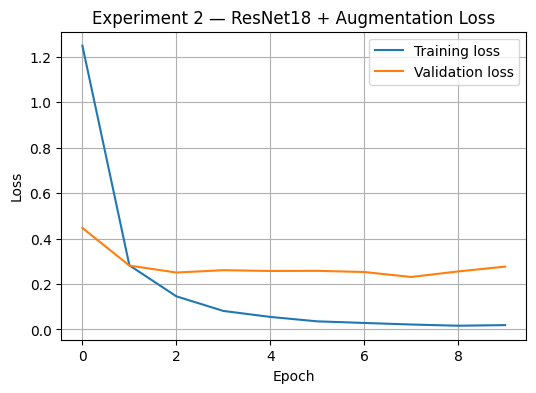

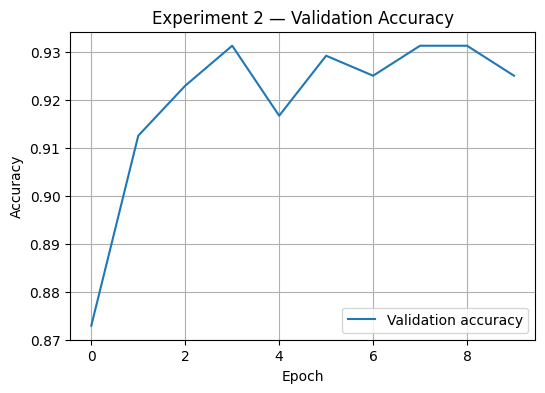

Experiment 0: 49.79%
Experiment 1: 93.33%
Experiment 2: 93.12%
Best Experiment 2 epoch: 4


In [33]:
plt.figure(figsize=(6, 4))
plt.plot(exp2_history['train_loss'], label='Training loss')
plt.plot(exp2_history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 2 — ResNet18 + Augmentation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(exp2_history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 2 — Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

best_exp2_acc = max(exp2_history['val_acc'])
best_exp2_epoch = exp2_history['val_acc'].index(best_exp2_acc) + 1

print(f"Experiment 0: 49.79%")
print(f"Experiment 1: {best_exp1_acc * 100:.2f}%")
print(f"Experiment 2: {best_exp2_acc * 100:.2f}%")
print(f"Best Experiment 2 epoch: {best_exp2_epoch}")

### Experiment 2 — ResNet18 with Data Augmentation

**Objective.** Test whether moderate training-time data augmentation improves
generalization of the pretrained ResNet18.

**Hypothesis.**
Experiment 1 achieved high validation accuracy, but training loss approached
zero while validation accuracy plateaued around 92–93%. I therefore
investigated whether increasing training-image diversity through augmentation
could reduce overfitting and improve validation performance.

**Configuration.**
- Architecture: ImageNet-pretrained ResNet18
- Input: 224 × 224 RGB
- Training augmentation: RandomResizedCrop(scale=(0.8, 1.0)) and
  RandomHorizontalFlip(p=0.5)
- Validation preprocessing: deterministic resize and ImageNet normalization
- Batch size: 64
- Optimizer: Adam
- Learning rate: 0.0001
- Loss: CrossEntropyLoss
- Epochs: 10
- Random seed: 0
- Same train/validation indices as Experiment 1

**Result.**
The augmented model achieved a best validation accuracy of **93.12% at epoch
4**. This was slightly lower than the **93.33%** achieved without augmentation
in Experiment 1. Final validation accuracy was **92.50%**.

**Observation.**
Training loss decreased from 1.2484 to 0.0191, while validation loss reached
its lowest region during the middle epochs and later increased to 0.2765.
Although augmentation prevented training loss from becoming as small as in
Experiment 1, it did not produce higher validation accuracy.

**Interpretation.**
The augmentation strategy acted as additional regularization, but the selected
RandomResizedCrop and horizontal-flip configuration did not measurably improve
validation accuracy. The difference between Experiments 1 and 2 is small, so
the result does not show that augmentation is generally harmful. It only shows
that this specific augmentation configuration provided no advantage under the
current training setup.

**Decision.**
I rejected this augmentation configuration as an improvement and retained the
non-augmented Experiment 1 ResNet18 as the current best model.

# Experiment 3 — Learning-Rate Scheduling

## Hypothesis

Experiment 1 reached 93.33% validation accuracy very quickly and then
plateaued. This suggests that a fixed learning rate may not be ideal throughout
the entire fine-tuning process.

I studied learning-rate scheduling and investigated whether gradually reducing
the learning rate could allow smaller parameter updates during later epochs,
potentially refining the pretrained model without changing its architecture or
input pipeline.

This experiment returns to the non-augmented preprocessing from Experiment 1
and changes the optimization schedule.

In [34]:
def train_model_with_scheduler(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs,
    device
):
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    start_time = time.time()

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        total = 0

        current_lr = optimizer.param_groups[0]['lr']

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += images.size(0)

        train_loss = running_loss / total

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            device
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        scheduler.step()

        elapsed = time.time() - start_time

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_acc:.4f} | "
            f"lr {current_lr:.6f} | "
            f"{elapsed:.1f}s"
        )

    model.load_state_dict(best_state)

    print(f"Best validation accuracy: {best_val_acc:.4f}")

    return model, history

In [35]:
set_random_seed(SEED)

exp3_model = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features = exp3_model.fc.in_features
exp3_model.fc = nn.Linear(num_features, num_classes)

exp3_model = exp3_model.to(device)

exp3_optimizer = optim.Adam(
    exp3_model.parameters(),
    lr=1e-4
)

exp3_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    exp3_optimizer,
    T_max=10,
    eta_min=1e-6
)

print("Experiment 3 configuration")
print("--------------------------")
print("Model: ResNet18")
print("Pretraining: ImageNet")
print("Input: 224 x 224 RGB")
print("Augmentation: None")
print("Optimizer: Adam")
print("Initial learning rate: 0.0001")
print("Scheduler: CosineAnnealingLR")
print("Minimum learning rate: 0.000001")
print("Epochs: 10")

Experiment 3 configuration
--------------------------
Model: ResNet18
Pretraining: ImageNet
Input: 224 x 224 RGB
Augmentation: None
Optimizer: Adam
Initial learning rate: 0.0001
Scheduler: CosineAnnealingLR
Minimum learning rate: 0.000001
Epochs: 10


In [36]:
exp3_model, exp3_history = train_model_with_scheduler(
    exp3_model,
    exp1_train_loader,
    exp1_val_loader,
    exp3_optimizer,
    exp3_scheduler,
    epochs=10,
    device=device
)

Epoch 01/10 | train loss 1.2511 | val loss 0.4111 | val acc 0.8896 | lr 0.000100 | 9.7s
Epoch 02/10 | train loss 0.2253 | val loss 0.2817 | val acc 0.9187 | lr 0.000098 | 18.6s
Epoch 03/10 | train loss 0.0815 | val loss 0.2486 | val acc 0.9229 | lr 0.000091 | 28.9s
Epoch 04/10 | train loss 0.0379 | val loss 0.2464 | val acc 0.9292 | lr 0.000080 | 39.0s
Epoch 05/10 | train loss 0.0231 | val loss 0.2316 | val acc 0.9313 | lr 0.000066 | 47.8s
Epoch 06/10 | train loss 0.0175 | val loss 0.2324 | val acc 0.9271 | lr 0.000051 | 58.9s
Epoch 07/10 | train loss 0.0160 | val loss 0.2342 | val acc 0.9271 | lr 0.000035 | 69.0s
Epoch 08/10 | train loss 0.0146 | val loss 0.2317 | val acc 0.9271 | lr 0.000021 | 77.6s
Epoch 09/10 | train loss 0.0125 | val loss 0.2324 | val acc 0.9187 | lr 0.000010 | 87.9s
Epoch 10/10 | train loss 0.0126 | val loss 0.2295 | val acc 0.9229 | lr 0.000003 | 97.1s
Best validation accuracy: 0.9313


In [37]:
best_exp3_acc = max(exp3_history['val_acc'])
best_exp3_epoch = exp3_history['val_acc'].index(best_exp3_acc) + 1

print(f"Experiment 0: 49.79%")
print(f"Experiment 1: {best_exp1_acc * 100:.2f}%")
print(f"Experiment 2: {best_exp2_acc * 100:.2f}%")
print(f"Experiment 3: {best_exp3_acc * 100:.2f}%")
print(f"Best Experiment 3 epoch: {best_exp3_epoch}")

Experiment 0: 49.79%
Experiment 1: 93.33%
Experiment 2: 93.12%
Experiment 3: 93.12%
Best Experiment 3 epoch: 5


### Experiment 3 — Result and Analysis

**Result.**
The cosine learning-rate scheduling experiment achieved a best validation
accuracy of **93.13% at epoch 5**. This was slightly below the **93.33%**
obtained by Experiment 1 using a fixed learning rate.

**Optimization behavior.**
The learning rate decreased gradually from 0.000100 to approximately 0.000003
over the 10 epochs. Validation accuracy increased from 88.96% in epoch 1 to
93.13% in epoch 5 and then remained around 91.88–92.71% during the remaining
epochs.

Training loss continued decreasing and reached 0.0126, while validation loss
remained substantially higher at approximately 0.23 near the end of training.

**Interpretation.**
Cosine learning-rate decay produced stable fine-tuning but did not improve the
best validation accuracy. The 93.13% result was 0.20 percentage points below
the fixed-learning-rate Experiment 1 result.

Because the difference is small, this experiment does not establish that
learning-rate scheduling is generally worse. It shows that this particular
cosine schedule did not provide a measurable improvement for the current
ResNet18 training setup.

**Decision.**
I retained Experiment 1 as the selected configuration because it achieved the
highest validation accuracy (**93.33%**) while also using a simpler fixed
learning-rate training procedure.

# Experiment 4 — Increasing CNN Capacity with ResNet50

## Hypothesis

Experiments 1–3 showed that ImageNet-pretrained ResNet18 consistently reaches
approximately 93% validation accuracy. Neither moderate data augmentation nor
cosine learning-rate scheduling improved this result.

This suggests that optimization alone may not be the primary limitation.

I therefore investigated whether increasing CNN model capacity could provide
more discriminative visual representations for the 16-class scene
classification task.

I selected ImageNet-pretrained ResNet50 as a higher-capacity CNN while
retaining the same 224 × 224 RGB preprocessing and validation split.

The hypothesis is that the deeper residual network may capture more complex
visual features and improve validation accuracy beyond the ResNet18 plateau.

In [39]:
from torchvision.models import resnet50, ResNet50_Weights

set_random_seed(SEED)

exp4_model = resnet50(weights=ResNet50_Weights.DEFAULT)

num_features = exp4_model.fc.in_features
exp4_model.fc = nn.Linear(num_features, num_classes)

exp4_model = exp4_model.to(device)

exp4_optimizer = optim.Adam(
    exp4_model.parameters(),
    lr=1e-4
)

print("Experiment 4 configuration")
print("--------------------------")
print("Model: ResNet50")
print("Pretraining: ImageNet")
print("Input: 224 x 224 RGB")
print("Augmentation: None")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: CrossEntropyLoss")
print("Epochs: 10")

trainable_params = sum(
    p.numel() for p in exp4_model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

Experiment 4 configuration
--------------------------
Model: ResNet50
Pretraining: ImageNet
Input: 224 x 224 RGB
Augmentation: None
Optimizer: Adam
Learning rate: 0.0001
Loss: CrossEntropyLoss
Epochs: 10
Trainable parameters: 23,540,816


In [40]:
exp4_model, exp4_history = train_model(
    exp4_model,
    exp1_train_loader,
    exp1_val_loader,
    exp4_optimizer,
    epochs=10,
    device=device
)

Epoch 01/10 | train loss 2.0638 | val loss 0.8293 | val acc 0.8313 | 23.3s
Epoch 02/10 | train loss 0.4653 | val loss 0.2637 | val acc 0.9333 | 49.3s
Epoch 03/10 | train loss 0.0940 | val loss 0.2090 | val acc 0.9396 | 74.2s
Epoch 04/10 | train loss 0.0400 | val loss 0.2332 | val acc 0.9354 | 97.9s
Epoch 05/10 | train loss 0.0243 | val loss 0.2059 | val acc 0.9313 | 122.7s
Epoch 06/10 | train loss 0.0178 | val loss 0.2070 | val acc 0.9417 | 147.6s
Epoch 07/10 | train loss 0.0110 | val loss 0.2165 | val acc 0.9437 | 171.9s
Epoch 08/10 | train loss 0.0103 | val loss 0.2358 | val acc 0.9417 | 196.6s
Epoch 09/10 | train loss 0.0083 | val loss 0.2665 | val acc 0.9354 | 220.8s
Epoch 10/10 | train loss 0.0060 | val loss 0.2772 | val acc 0.9417 | 245.4s
Best validation accuracy: 0.9437


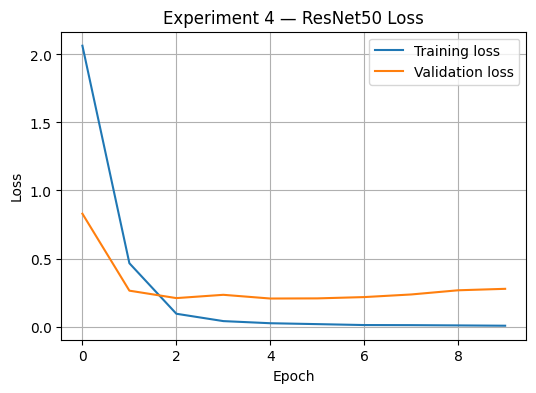

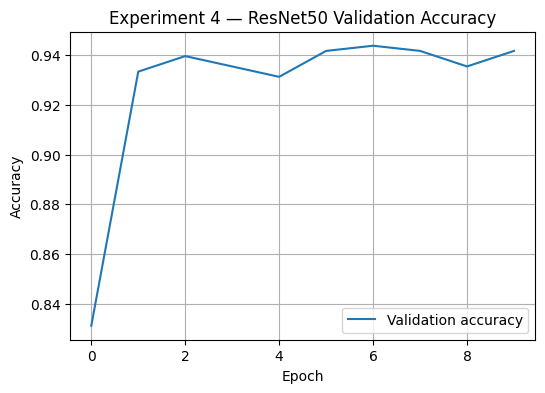

In [41]:
plt.figure(figsize=(6, 4))

plt.plot(
    exp4_history['train_loss'],
    label='Training loss'
)

plt.plot(
    exp4_history['val_loss'],
    label='Validation loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 4 — ResNet50 Loss')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(6, 4))

plt.plot(
    exp4_history['val_acc'],
    label='Validation accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 4 — ResNet50 Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Experiment 5 — Modern CNN Architecture: ConvNeXt-Tiny

### Hypothesis

Experiment 4 showed that increasing model capacity from ResNet18 to ResNet50 improved validation accuracy from 93.33% to 94.37%, but the training and validation loss curves still showed a generalization gap.

I studied modern CNN architectures and learned that ConvNeXt modernizes conventional convolutional networks using architectural design choices inspired by recent vision models while remaining a CNN-based architecture.

I therefore investigated whether an ImageNet-pretrained ConvNeXt-Tiny could provide stronger transferable visual representations than ResNet50.

To keep the comparison controlled, I retained the same 224 × 224 RGB input pipeline, train/validation split, optimizer, learning rate, loss function, and number of epochs used in the previous architecture experiments. The primary change in this experiment is the CNN architecture.

In [42]:
# ============================================================
# EXPERIMENT 5: ConvNeXt-Tiny
# ============================================================

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

set_random_seed(SEED)

# Load ImageNet-pretrained ConvNeXt-Tiny
exp5_model = convnext_tiny(
    weights=ConvNeXt_Tiny_Weights.DEFAULT
)

# Replace the final classification layer for our 16 classes
num_features = exp5_model.classifier[2].in_features
exp5_model.classifier[2] = nn.Linear(
    num_features,
    num_classes
)

exp5_model = exp5_model.to(device)

# Same optimizer and learning rate for controlled comparison
exp5_optimizer = optim.Adam(
    exp5_model.parameters(),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

trainable_params = sum(
    p.numel() for p in exp5_model.parameters()
    if p.requires_grad
)

print("Experiment 5 configuration")
print("--------------------------")
print("Model: ConvNeXt-Tiny")
print("Pretraining: ImageNet")
print("Input: 224 x 224 RGB")
print("Augmentation: None")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: CrossEntropyLoss")
print("Epochs: 10")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 184MB/s]


Experiment 5 configuration
--------------------------
Model: ConvNeXt-Tiny
Pretraining: ImageNet
Input: 224 x 224 RGB
Augmentation: None
Optimizer: Adam
Learning rate: 0.0001
Loss: CrossEntropyLoss
Epochs: 10
Trainable parameters: 27,832,432


In [43]:
# ============================================================
# EXPERIMENT 5: Training
# ============================================================

exp5_model, exp5_history = train_model(
    exp5_model,
    exp1_train_loader,
    exp1_val_loader,
    exp5_optimizer,
    epochs=10,
    device=device
)

Epoch 01/10 | train loss 1.3883 | val loss 0.4289 | val acc 0.9375 | 31.9s
Epoch 02/10 | train loss 0.2628 | val loss 0.1595 | val acc 0.9708 | 63.3s
Epoch 03/10 | train loss 0.0916 | val loss 0.1203 | val acc 0.9688 | 95.4s
Epoch 04/10 | train loss 0.0354 | val loss 0.1189 | val acc 0.9625 | 127.7s
Epoch 05/10 | train loss 0.0213 | val loss 0.1316 | val acc 0.9583 | 160.3s
Epoch 06/10 | train loss 0.0141 | val loss 0.1171 | val acc 0.9604 | 193.3s
Epoch 07/10 | train loss 0.0090 | val loss 0.1234 | val acc 0.9625 | 226.4s
Epoch 08/10 | train loss 0.0073 | val loss 0.1298 | val acc 0.9604 | 259.2s
Epoch 09/10 | train loss 0.0057 | val loss 0.1406 | val acc 0.9625 | 292.1s
Epoch 10/10 | train loss 0.0047 | val loss 0.1537 | val acc 0.9604 | 326.3s
Best validation accuracy: 0.9708


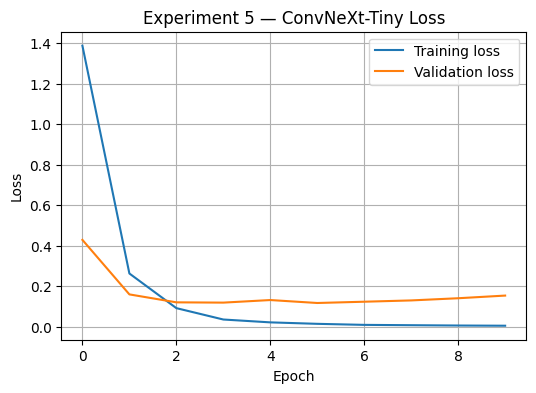

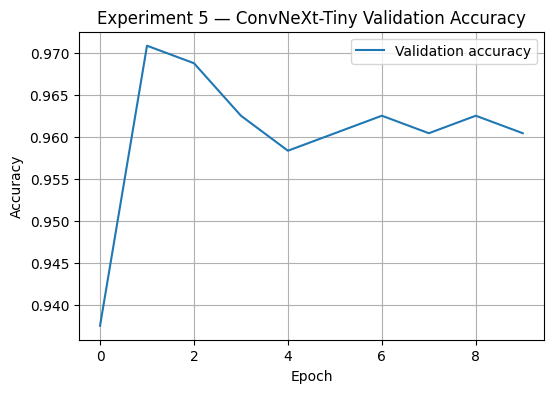

Experiment 0: 49.79%
Experiment 1: 93.33%
Experiment 2: 93.12%
Experiment 3: 93.12%


NameError: name 'best_exp4_acc' is not defined

In [44]:
# ============================================================
# EXPERIMENT 5: Learning curves
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    exp5_history['train_loss'],
    label='Training loss'
)

plt.plot(
    exp5_history['val_loss'],
    label='Validation loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 5 — ConvNeXt-Tiny Loss')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(6, 4))

plt.plot(
    exp5_history['val_acc'],
    label='Validation accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 5 — ConvNeXt-Tiny Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


best_exp5_acc = max(exp5_history['val_acc'])
best_exp5_epoch = exp5_history['val_acc'].index(best_exp5_acc) + 1

print(f"Experiment 0: 49.79%")
print(f"Experiment 1: {best_exp1_acc * 100:.2f}%")
print(f"Experiment 2: {best_exp2_acc * 100:.2f}%")
print(f"Experiment 3: {best_exp3_acc * 100:.2f}%")
print(f"Experiment 4: {best_exp4_acc * 100:.2f}%")
print(f"Experiment 5: {best_exp5_acc * 100:.2f}%")
print(f"Best Experiment 5 epoch: {best_exp5_epoch}")

## 6. Your turn: beat the baseline

This simple model should only be treated as a sanity check. Your objective is to substantially improve it.

Rather than asking an AI tool to ``make the accuracy higher,'' formulate hypotheses yourself. Examples of useful questions include whether the model is overfitting, whether color matters, whether stronger augmentation helps, whether a different CNN family is more appropriate, whether pretrained CNN features transfer well, or whether optimization/regularization is limiting performance.

For each important experiment, write down:

| Experiment | What changed? | Why did you try it? | Validation accuracy | What did you learn? |
|---|---|---|---:|---|
| Baseline | Starter TNet | Sanity check | 49.79% | Strong overfitting; training loss continued decreasing while validation performance plateaued |
| Experiment 1 | ImageNet-pretrained ResNet18, 224×224 RGB | 93.33% | Transfer learning dramatically improved generalization | |
| Experiment 2 | | | | |
| Final model | | | | |

**Do not use the test set to choose among these experiments.**

In [24]:
# FINAL TEST EVALUATION
# Run this only after you have selected your final model using validation results.
# Replace `model` with your final selected model/checkpoint.

test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

Final test loss: 1.8582
Final test accuracy: 0.4225


## 7. AI-assisted development checkpoint

Before submission, create `AI_USAGE.md` in your GitHub repository. You do **not** need to provide every prompt. Include:

1. the AI coding tool(s) you used;
2. 3--5 representative ways AI assisted you;
3. at least one AI suggestion that was incorrect, ineffective, or questionable;
4. how you tested, verified, corrected, or rejected that suggestion; and
5. one important architecture/experimental decision that **you** made.

A good entry describes the engineering/research interaction rather than saying only, ``I used ChatGPT to write code.''

### A useful habit
When AI generates code, ask yourself before running it:
- What do I expect this code to do?
- What assumption is it making about tensor shape/data/model behavior?
- How will I know if it is wrong?
- What experiment would distinguish a real improvement from noise?

## 8. GitHub and submission requirements

All assignment code must be maintained in **GitHub** (not GitLab). Your repository should contain a meaningful commit history and, at minimum:

```text
README.md
AI_USAGE.md
training / model code
inference or evaluation code
requirements.txt or environment information
final checkpoint or a link to it
reproduction instructions
```

Do not create the entire repository as a single commit immediately before the deadline. Use Git throughout development as you would in a real research or engineering project.

Your final submission is a **maximum two-page PDF report** containing the working GitHub link. The report should clearly state your best result, validation/model-selection strategy, final recipe, important experiments, at least one failure analysis, and a brief AI+human reflection.

Friendly discussion and brainstorming are encouraged, but your implementation, experiments, report, and repository must be your own. Do not share code, checkpoints, detailed hyperparameters, or test predictions before the deadline.

The instructor may ask you to explain any important component of your submitted system. You are responsible for understanding all code in your final repository, including AI-generated code.

**Deadline: September 25, 2026 at 11:59 PM EDT.**

Good luck — and treat this as your first small computer vision research project of the semester.